# 01 — Evaluation rigor: measuring a high-variance agent honestly

Poker (like a trading backtest) is *high variance*: a few unlucky deals can swamp a real edge. This notebook reproduces — straight from the committed `results/*.json`, **no retraining** — how this project decides whether an edge is real:

1. **Paired seeds + bootstrap CIs + a paired t-test** on the headline RL-vs-myopic match.
2. **Variance reduction** (duplicate/mirror matching and an all-in-EV control variate, the DIVAT/AIVAT family — `references.md` §2).
3. The honest verdict: *the edges are directional but marginal*, and rigor — not a headline win — is the deliverable.


In [1]:
import os, sys, json
# Walk up to the repo root (works whether the kernel cwd is notebooks/ or root).
ROOT = os.getcwd()
while not (os.path.isdir(os.path.join(ROOT, "results"))
          and os.path.isdir(os.path.join(ROOT, "src"))) \
        and os.path.dirname(ROOT) != ROOT:
    ROOT = os.path.dirname(ROOT)
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

from IPython.display import Image, display

def load(name):
    with open(os.path.join(ROOT, "results", name)) as f:
        return json.load(f)

def fig(name):
    display(Image(filename=os.path.join(ROOT, "figures", name)))
print("repo root resolved:", os.path.basename(ROOT))

repo root resolved: poker-simulation


## 1. The headline edge, recomputed from per-seed PnL

`results/headline_history.json` stores the per-seed chip differences of the final RL agent vs the myopic EV baseline. We re-run the project's own `bootstrap_ci` and `paired_t_test` on that raw vector — the printed CI should match the committed one exactly (that is the reproduction).

In [2]:
from src.stats import bootstrap_ci, paired_t_test
h = load("headline_history.json")["final"]
diffs = h["per_seed_diffs"]
ci = bootstrap_ci(diffs)
t = paired_t_test(diffs)
print(f"matches: {h['wins']}/{h['n_seeds']}  "
      f"mean chip diff = {ci['mean']:+.1f}")
print(f"95% bootstrap CI = [{ci['lo']:+.0f}, {ci['hi']:+.0f}]  "
      f"(committed: [{h['ci95']['lo']:+.0f}, {h['ci95']['hi']:+.0f}])")
print(f"paired t-test p = {t['p_value']:.4f}")
print()
print("Read it honestly: the mean is positive, but the CI lower bound\n"
      "sits at/near 0 — a real but MARGINAL edge, not a decisive win.")

matches: 32/50  mean chip diff = +560.0
95% bootstrap CI = [+0, +1040]  (committed: [+0, +1040])
paired t-test p = 0.0466

Read it honestly: the mean is positive, but the CI lower bound
sits at/near 0 — a real but MARGINAL edge, not a decisive win.


## 2. Variance reduction — the same edge, measured four ways

`results/variance_reduction.json` measures one fixed edge (Myopic vs Aggro, 120 paired seeds) four ways. Duplicate/**mirror matching** (same deck, swapped seats) cancels seat/deck luck and narrows the CI; the all-in-EV control variate is ~neutral in this *bust-match* format (its big gains are for per-hand win-rate estimation).

In [3]:
vr = load("variance_reduction.json")
print(f"{'arm':14s} {'mean':>8s} {'CI width':>10s} {'% of raw':>9s}")
for a in vr["arms"]:
    print(f"{a['arm']:14s} {a['mean']:+8.1f} {a['ci_width']:10.0f} "
          f"{a['ci_width_vs_raw']:8.0%}")

arm                mean   CI width  % of raw
raw               +33.3        712     100%
mirror            +56.8        464      65%
luck_adjusted     +42.6        704      99%
mirror+luck       +63.1        458      64%


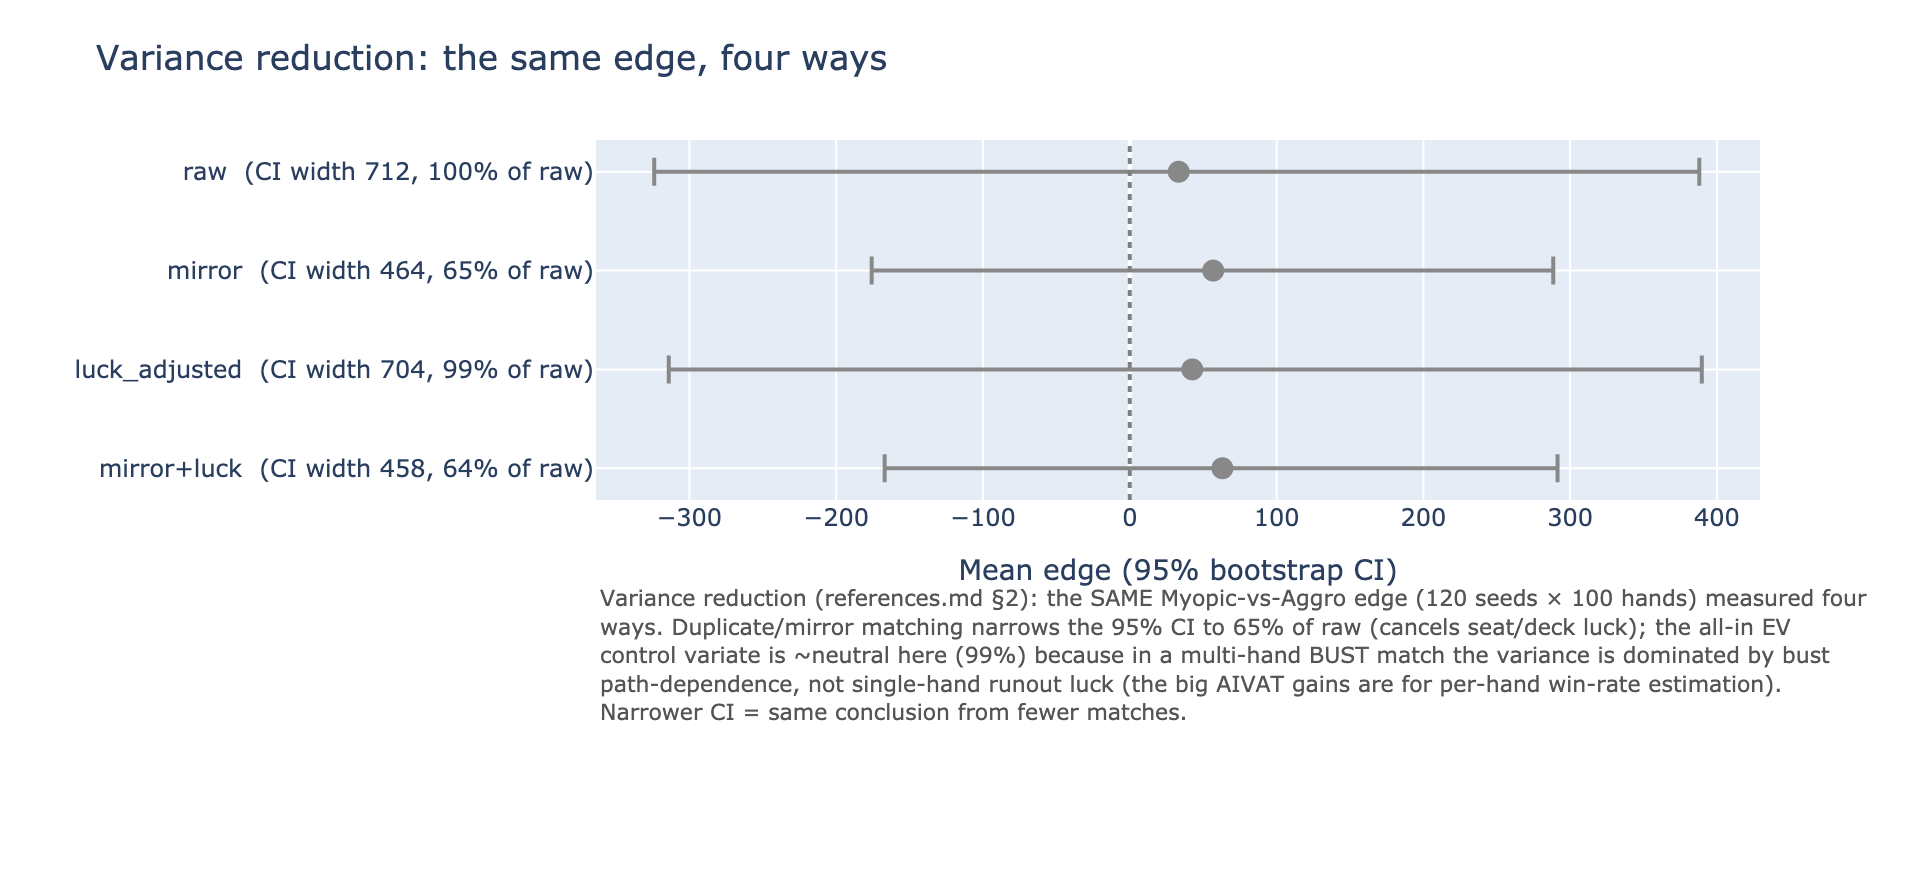

In [4]:
fig("variance_reduction.png")

## 3. Are *any* of the headline edges real?

The executive summary puts every claimed edge on one axis with its 95% bootstrap CI. Gray = the CI straddles 0 (within per-seed noise).

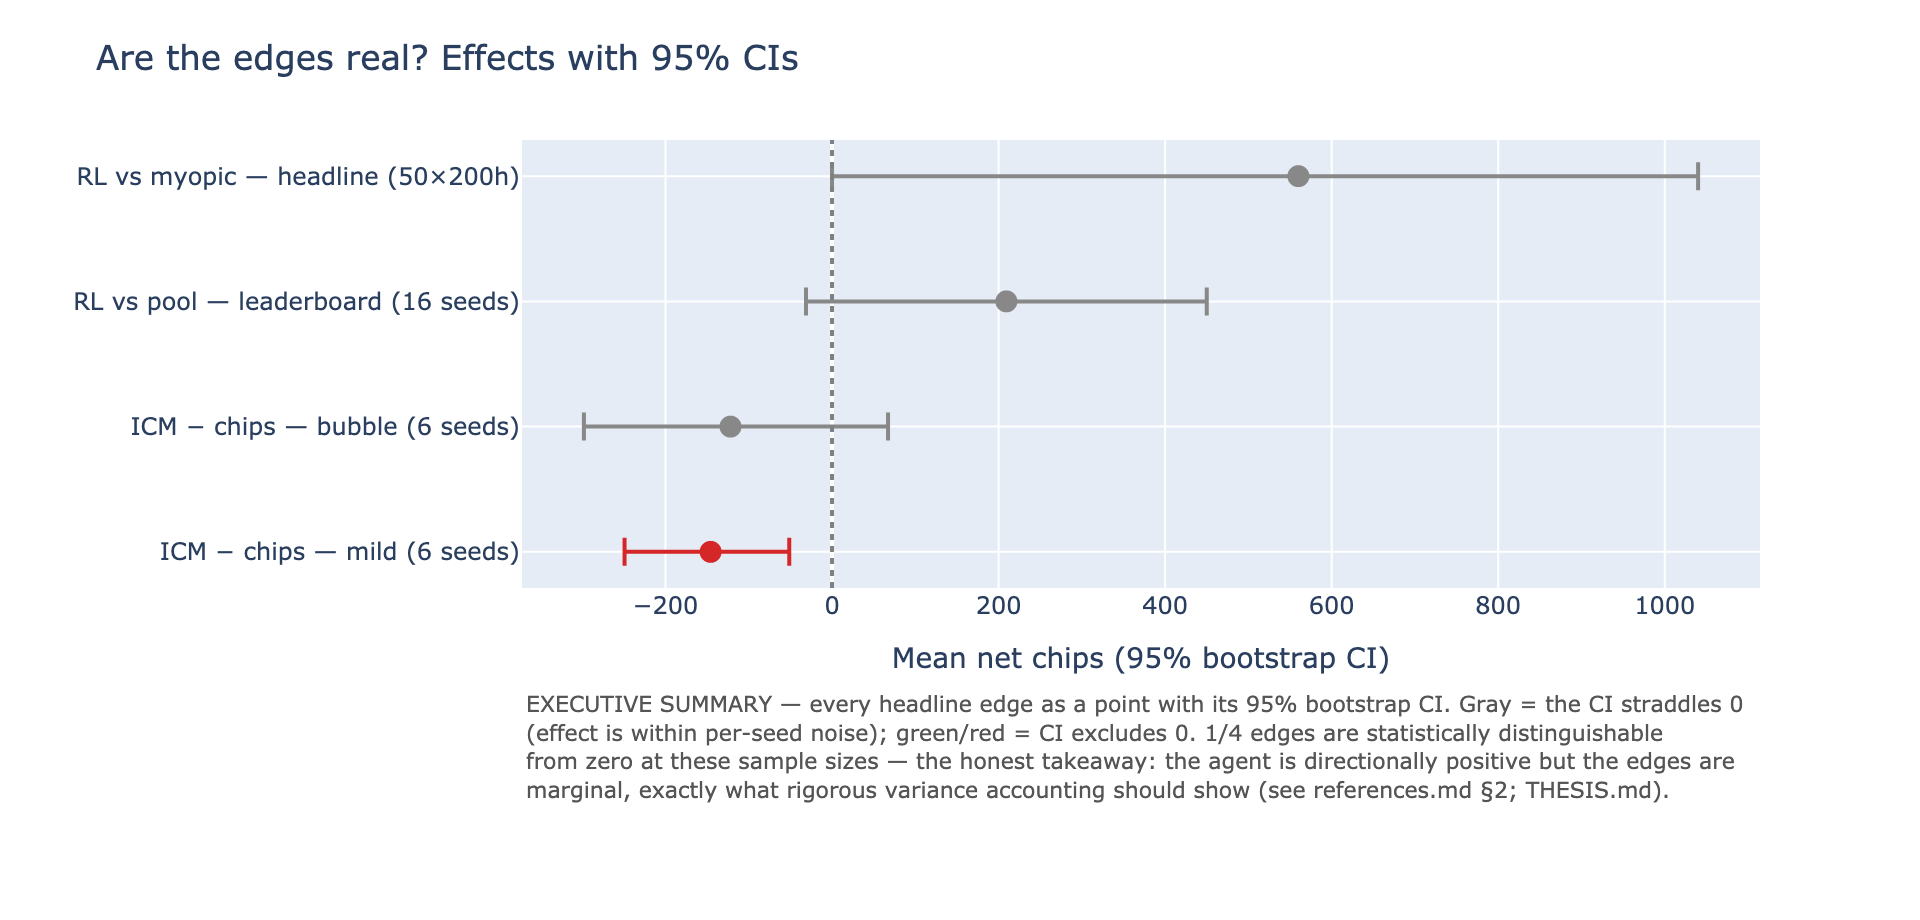

In [5]:
fig("exec_summary.png")

### Honest takeaway

The RL agent is **directionally positive but marginal**; most CIs straddle 0 at these sample sizes, and the ICM/Kelly reward is *significantly negative* on the mild ladder. This is the correct finding for a single-developer DQN in a high-variance game. The transferable artifact is the **measurement discipline** — paired design, bootstrap CIs, variance reduction — not a headline number. See `THESIS.md` and `references.md` §2.